### Import Library, path dan gambar

Berhasil memuat gambar: abnomen.jpg
Ukuran gambar: 800 x 734 piksel


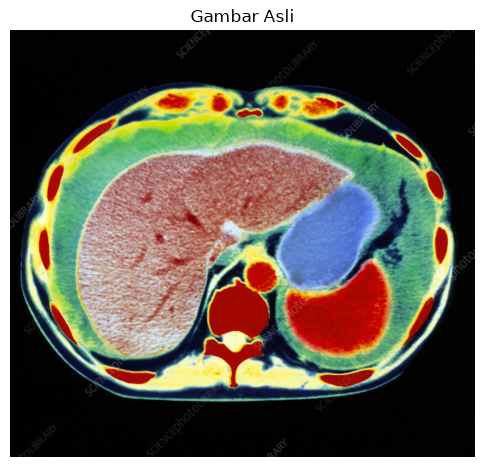

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- KONFIGURASI PATH ---
# Path Gambar Input (abnomen.jpg)
IMAGE_PATH = r"D:\Semester 5\Data Citra\Kuliah-Data-Citra\Dataset\abnomen.jpg"

# Path Folder Output Hasil
OUTPUT_DIR = r"D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil"

# Buat folder Hasil jika belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ambil nama file asli (misal: "abnomen.jpg")
filename = os.path.basename(IMAGE_PATH)

# Baca Gambar Input
img1 = cv2.imread(IMAGE_PATH)

if img1 is None:
    print(f"Gagal membaca gambar dari: {IMAGE_PATH}")
else:
    print(f"Berhasil memuat gambar: {filename}")
    print(f"Ukuran gambar: {img1.shape[1]} x {img1.shape[0]} piksel")

    # Tampilkan Gambar Asli
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    plt.title("Gambar Asli")
    plt.axis("off")
    plt.show()

## Transformasi Skala

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\Skala_2x2_abnomen.jpg


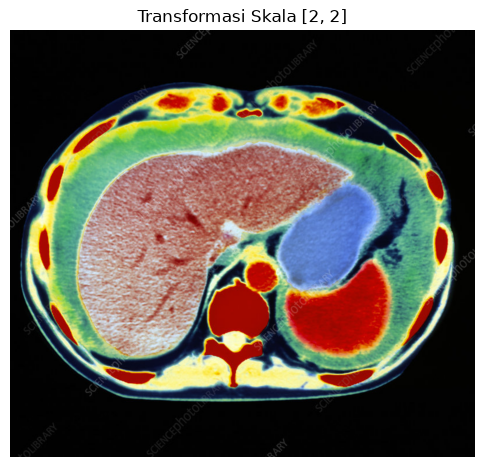

In [2]:
# Vektor Skala [Skala Lebar/X, Skala Tinggi/Y]
vektor_skala = [2, 2]

tinggi_baru = int(img1.shape[0] * vektor_skala[1])
lebar_baru = int(img1.shape[1] * vektor_skala[0])

# Buat kanvas baru
img_skala = np.zeros((tinggi_baru, lebar_baru, 3), dtype=np.uint8)

# Mapping piksel
for i in range(img_skala.shape[0]):
    for j in range(img_skala.shape[1]):
        sumber_i = int(i / vektor_skala[1])
        sumber_j = int(j / vektor_skala[0])

        if img1.shape[0] > sumber_i and img1.shape[1] > sumber_j:
            img_skala[i, j, :] = img1[sumber_i, sumber_j, :]

# Simpan Hasil
save_path_skala = os.path.join(OUTPUT_DIR, f"Skala_{vektor_skala[0]}x{vektor_skala[1]}_{filename}")
cv2.imwrite(save_path_skala, img_skala)
print(f"Selesai! Disimpan ke: {save_path_skala}")

# Tampilkan Hasil
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_skala, cv2.COLOR_BGR2RGB))
plt.title(f"Transformasi Skala {vektor_skala}")
plt.axis("off")
plt.show()

## Transformasi Translasi (pergeseran)

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\Translasi_50_0_abnomen.jpg


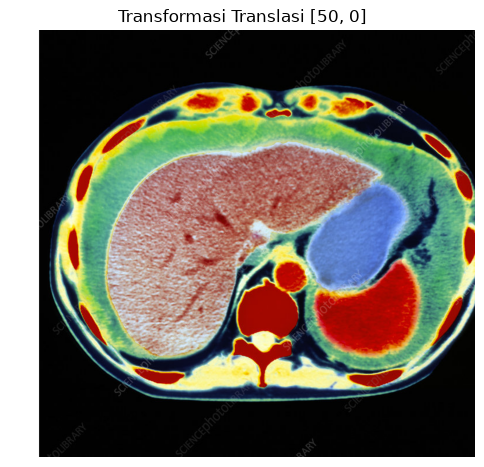

In [3]:
# Vektor Translasi [Geser X (Kanan), Geser Y (Bawah)]
vektor_translasi = [50, 0]

# Buat kanvas berukuran sama dengan gambar asli
img_translasi = np.zeros(img1.shape, dtype=np.uint8)

# Mapping piksel
for i in range(img_translasi.shape[0]):
    for j in range(img_translasi.shape[1]):
        if img1.shape[1] > j - vektor_translasi[0] >= 0 and img1.shape[0] > i + vektor_translasi[1] >= 0:
            img_translasi[i, j, :] = img1[i + vektor_translasi[1], j - vektor_translasi[0], :]
        else:
            # Latar belakang putih untuk daerah kosong
            img_translasi[i, j] = np.array([255, 255, 255])

# Simpan Hasil
save_path_translasi = os.path.join(OUTPUT_DIR, f"Translasi_{vektor_translasi[0]}_{vektor_translasi[1]}_{filename}")
cv2.imwrite(save_path_translasi, img_translasi)
print(f"Selesai! Disimpan ke: {save_path_translasi}")

# Tampilkan Hasil
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_translasi, cv2.COLOR_BGR2RGB))
plt.title(f"Transformasi Translasi {vektor_translasi}")
plt.axis("off")
plt.show()

## Transformasi Rotasi (perputaran)

Selesai! Disimpan ke: D:\Semester 5\Data Citra\Kuliah-Data-Citra\Tugas 2\Hasil\Rotasi_270_abnomen.jpg


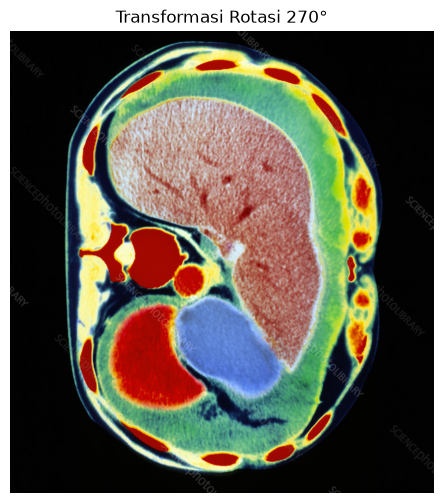

In [4]:
def rotasi_90(img):
    # Fungsi memutar gambar 90 derajat searah jarum jam
    img_new = np.zeros((img.shape[1], img.shape[0], 3), dtype=np.uint8)
    for i in range(img_new.shape[0]):
        for j in range(img_new.shape[1]):
            img_new[i, j, :] = img[j, img_new.shape[0] - 1 - i, :]
    return img_new

derajat = 270

if derajat % 90 != 0:
    print("Sudut perputaran tidak valid! Harus kelipatan 90.")
else:
    img_rotasi = img1.copy()
    kuadran = int(derajat / 90)

    for _ in range(kuadran % 4):
        img_rotasi = rotasi_90(img_rotasi)

    # Simpan Hasil
    save_path_rotasi = os.path.join(OUTPUT_DIR, f"Rotasi_{derajat}_{filename}")
    cv2.imwrite(save_path_rotasi, img_rotasi)
    print(f"Selesai! Disimpan ke: {save_path_rotasi}")

    # Tampilkan Hasil
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_rotasi, cv2.COLOR_BGR2RGB))
    plt.title(f"Transformasi Rotasi {derajat}°")
    plt.axis("off")
    plt.show()